Student Performance Factors Analysis
Dataset: Student Performance Factors (Kaggle)

=== STEP 1: LOADING DATASET ===
Dataset file not found. Creating a sample dataset with similar structure...
Sample dataset created successfully!
Dataset shape: (6607, 20)

First 5 rows:
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0       4.787359   88.908214                 High              Medium   
1       2.988929   92.057960               Medium                High   
2       2.764567   91.192660               Medium              Medium   
3       2.764605   95.434102               Medium                High   
4       9.299429   71.890396                 High              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                        Yes     5.245561        97.543446             High   
1                         No     6.409181        52.370526           Medium   
2                        Yes     6.567788        74.95

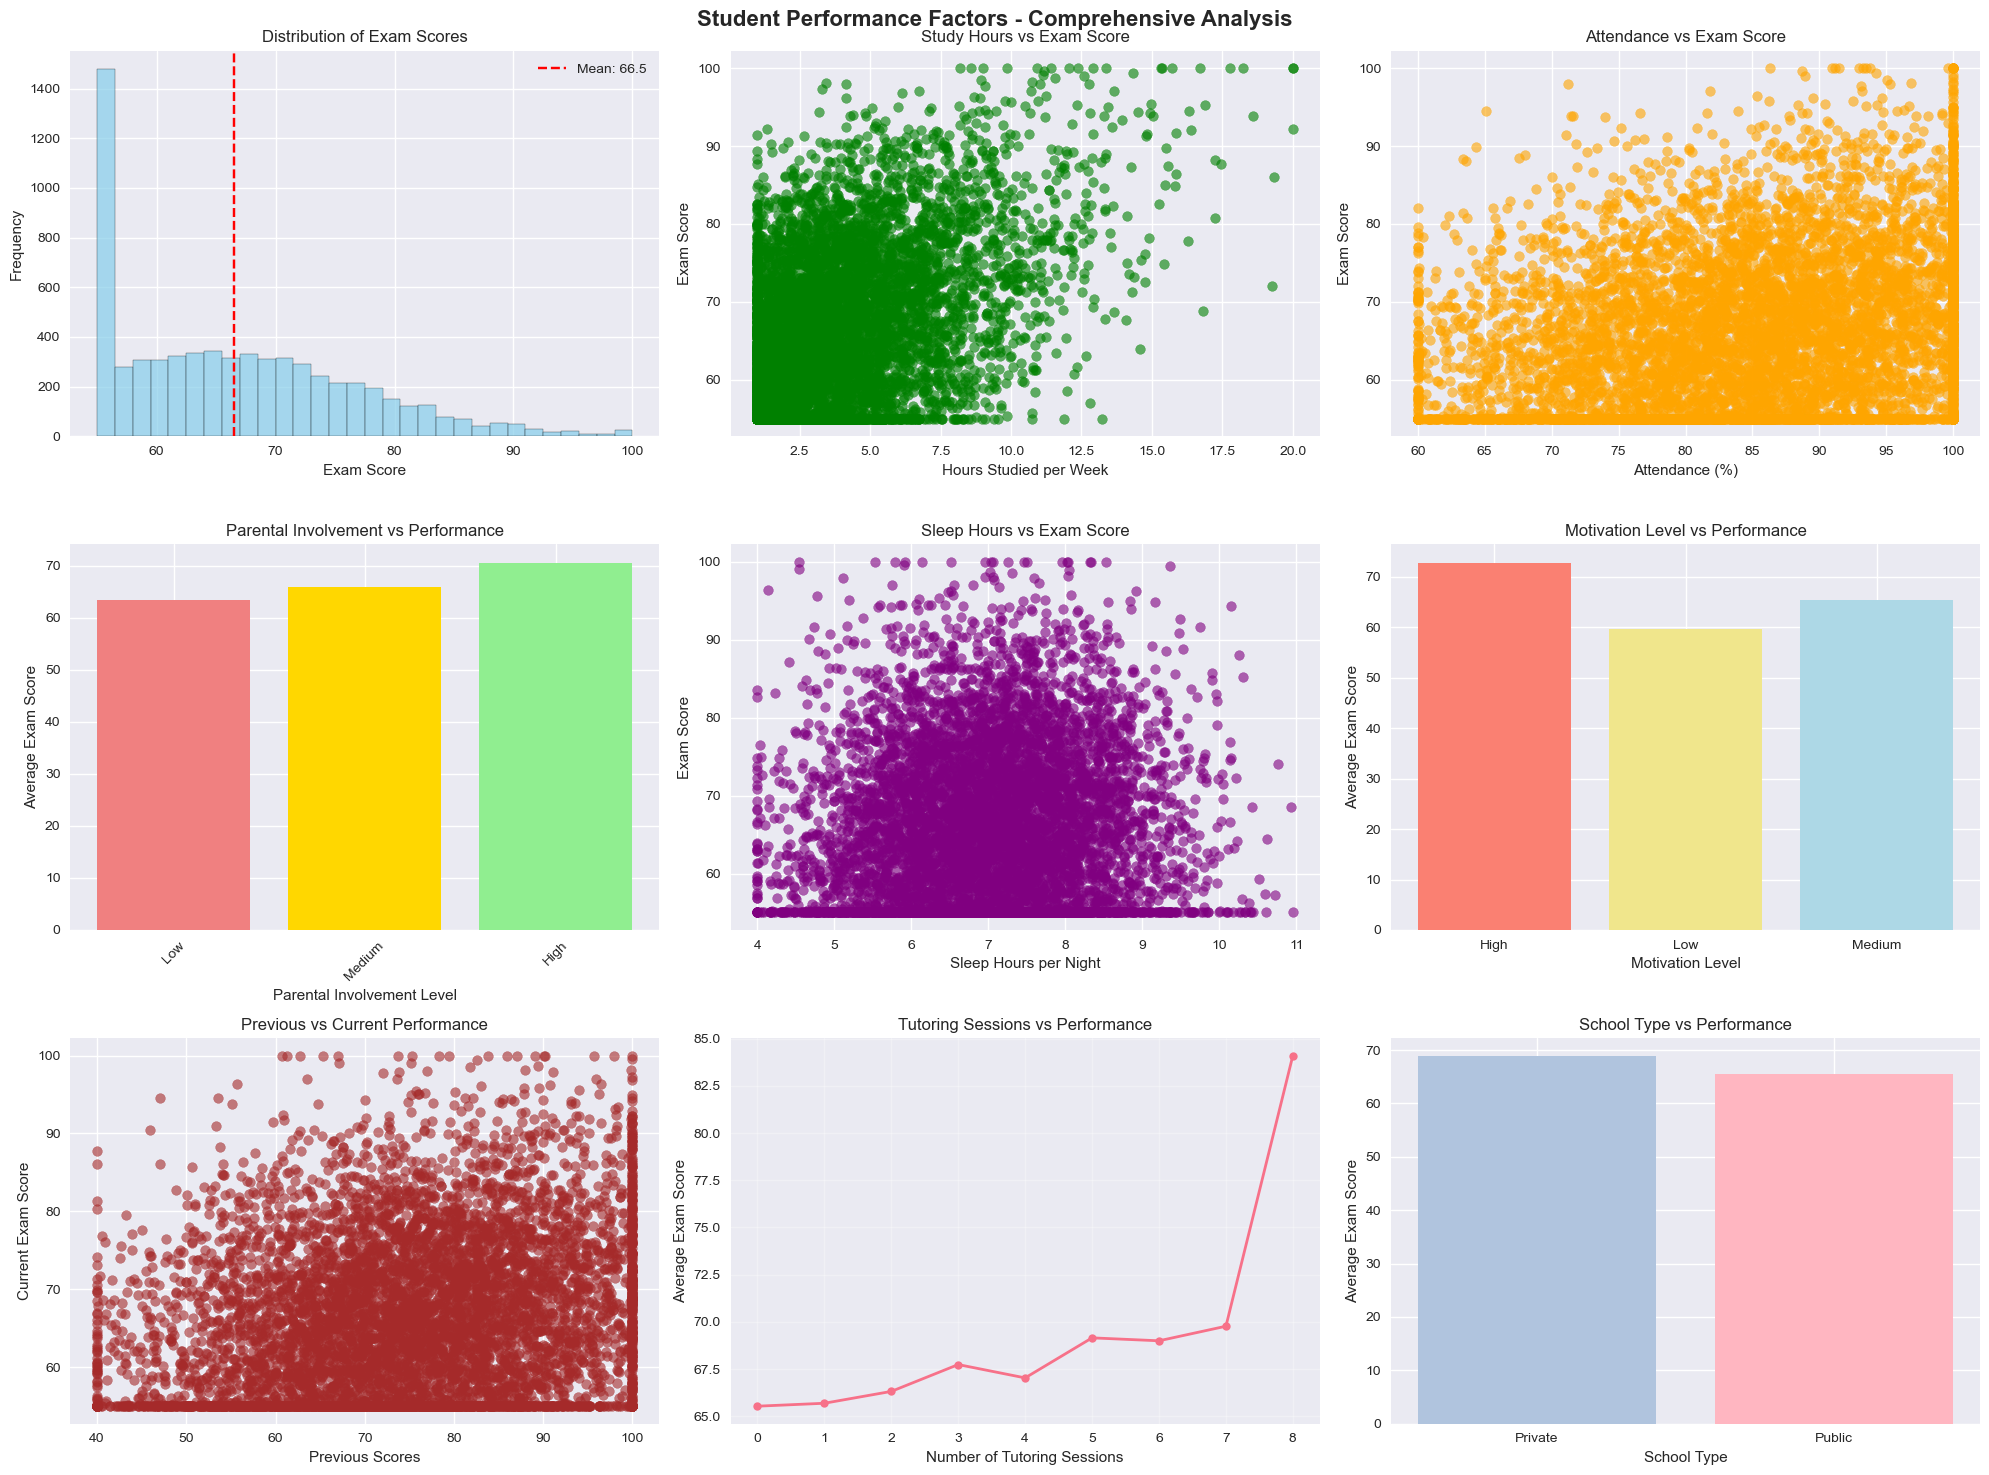


Correlation Analysis:
Correlation with Exam Score:
Exam_Score           1.000
Hours_Studied        0.441
Attendance           0.269
Previous_Scores      0.231
Tutoring_Sessions    0.095
Sleep_Hours          0.076
Physical_Activity   -0.021
Name: Exam_Score, dtype: float64


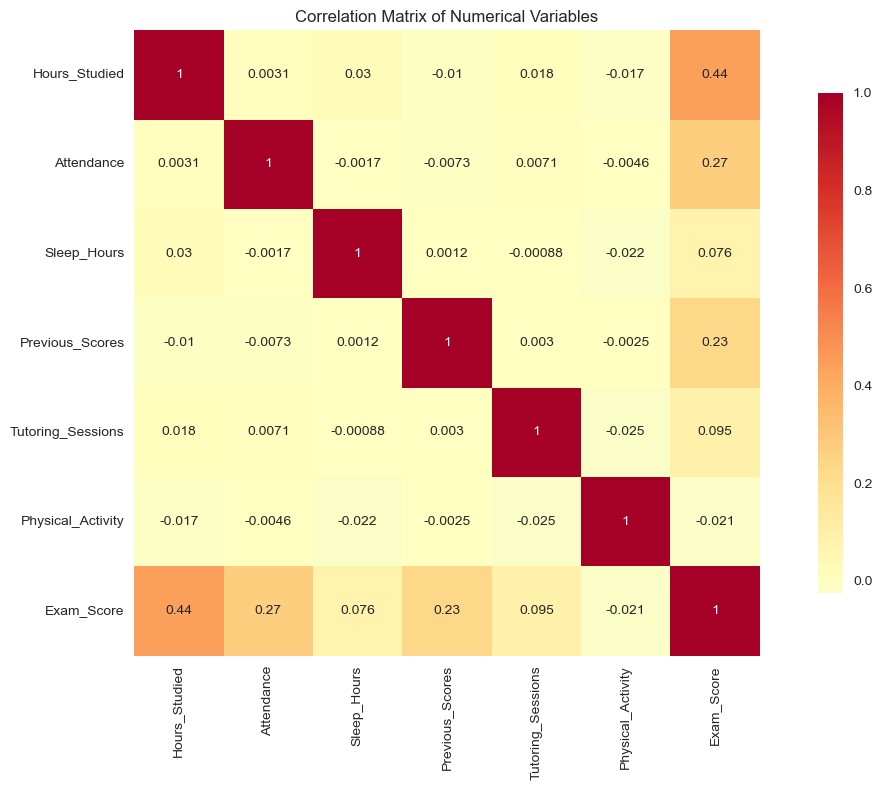


=== STEP 4: DATA PREPROCESSING ===
Data preprocessing completed!
All categorical variables converted to numerical format
Final dataset shape: (6607, 20)

=== STEP 5: FEATURE SELECTION ===
Features selected: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
Target variable: Exam_Score
Feature matrix shape: (6607, 19)
Training set size: 5285 samples
Testing set size: 1322 samples

=== STEP 6: SIMPLE LINEAR REGRESSION ===
Using most correlated feature: Hours_Studied
Simple Linear Regression Results (Hours_Studied):
R² Score: 0.1957
RMSE: 9.134
MAE: 7.530


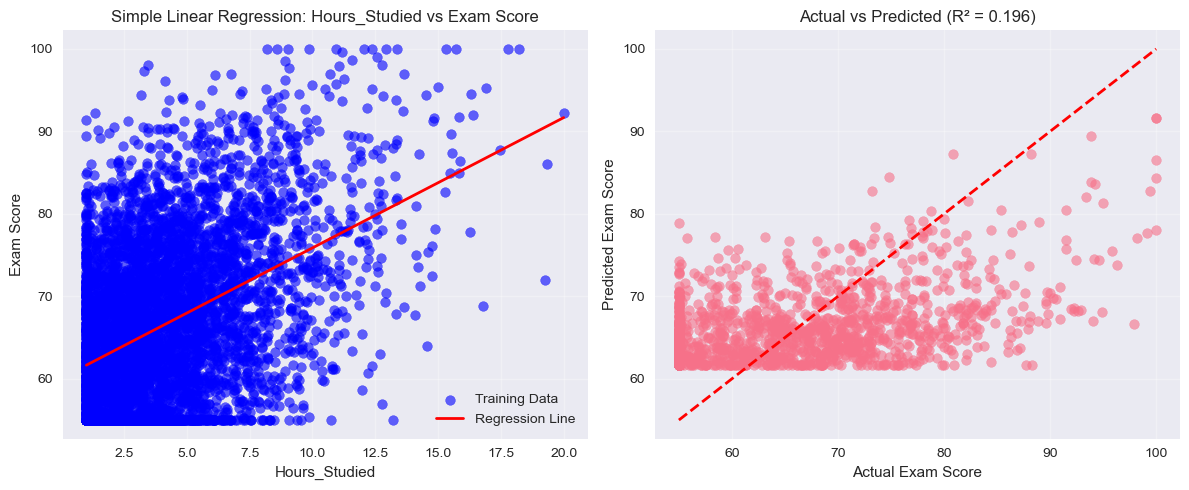


=== STEP 7: MULTIPLE LINEAR REGRESSION ===
Multiple Linear Regression Results:
R² Score: 0.7785
RMSE: 4.794
MAE: 3.848

Top 10 Most Important Features:
                       Feature  Coefficient  Abs_Coefficient
7             Motivation_Level       6.4778           6.4778
8              Internet_Access       4.0651           4.0651
15       Learning_Disabilities      -3.8878           3.8878
12                 School_Type       3.4886           3.4886
2         Parental_Involvement       3.4567           3.4567
3          Access_to_Resources       3.3505           3.3505
4   Extracurricular_Activities       2.3670           2.3670
0                Hours_Studied       1.5631           1.5631
9            Tutoring_Sessions       0.6161           0.6161
5                  Sleep_Hours       0.4882           0.4882

=== STEP 8: POLYNOMIAL REGRESSION ===
Polynomial Regression (Degree 2):
  R² Score: 0.2850
  RMSE: 8.612
Polynomial Regression (Degree 3):
  R² Score: 0.2860
  RMSE: 8.606

==

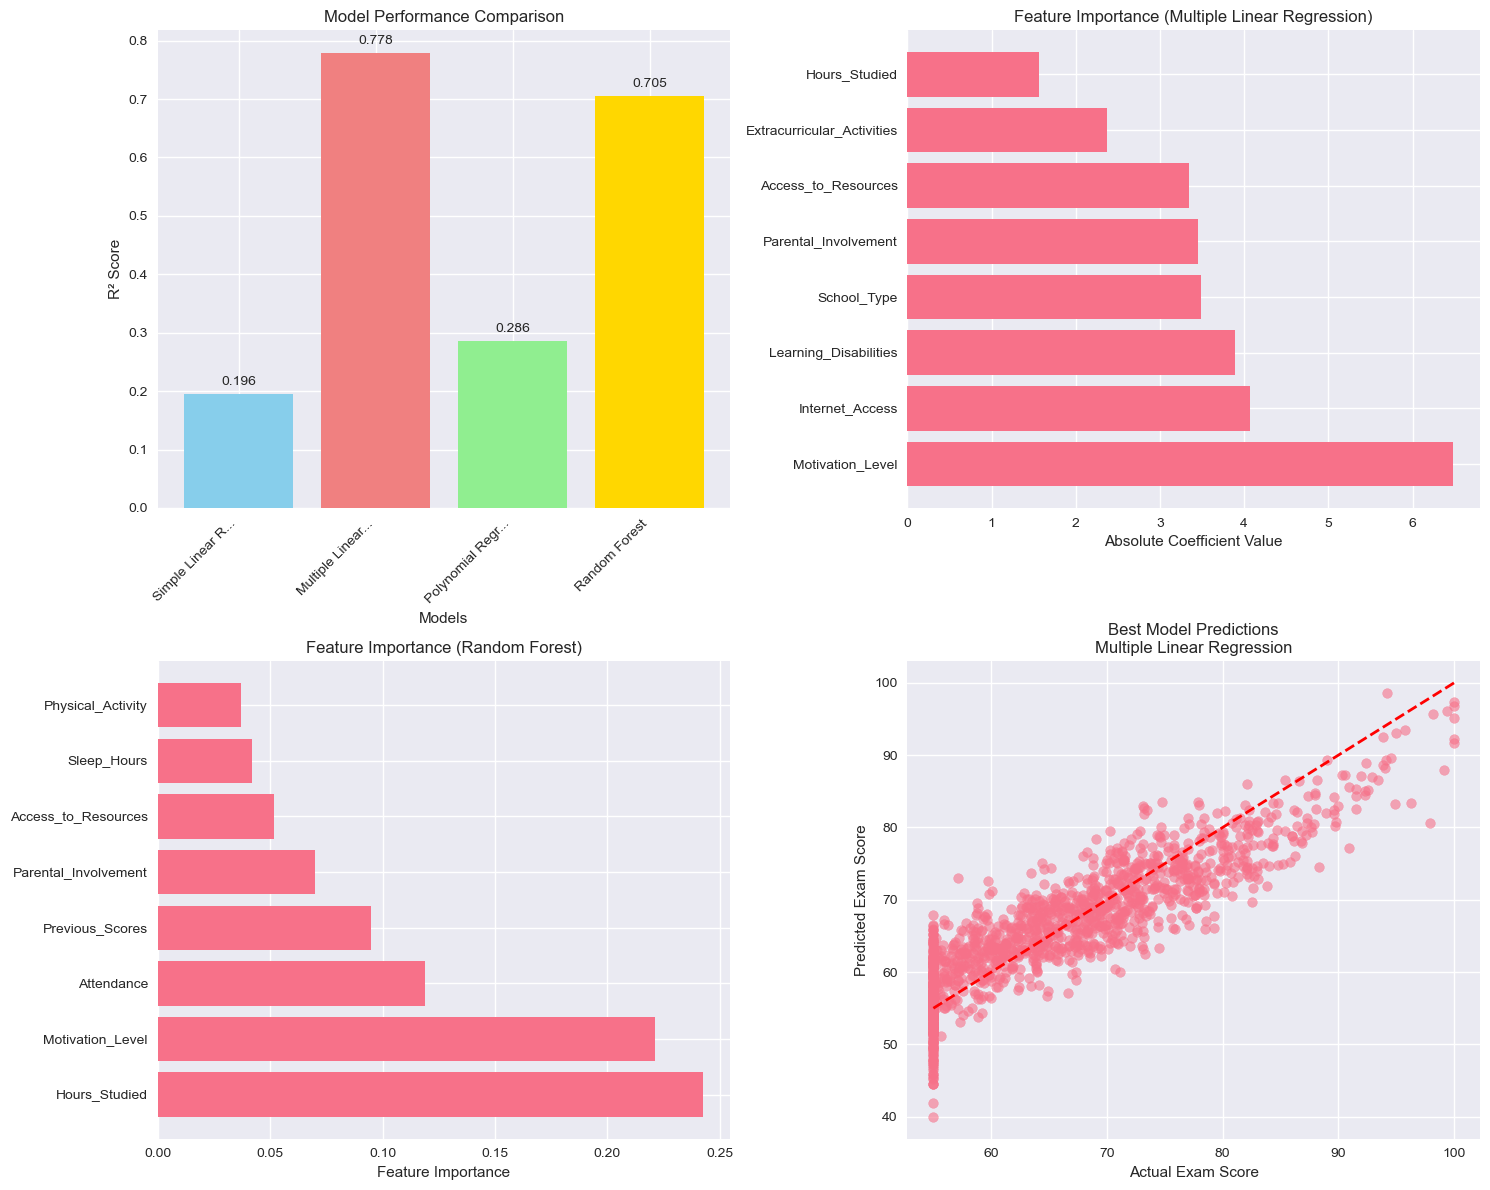


STUDENT PERFORMANCE FACTORS - ANALYSIS SUMMARY

DATASET OVERVIEW:
• Total Students Analyzed: 6,607
• Number of Features: 19
• Target Variable: Exam Score (Range: 55.0 - 100.0)

KEY PERFORMANCE FACTORS (Top 5):

• Motivation_Level: Coefficient = 6.478
• Internet_Access: Coefficient = 4.065
• Learning_Disabilities: Coefficient = -3.888
• School_Type: Coefficient = 3.489
• Parental_Involvement: Coefficient = 3.457

MODEL PERFORMANCE SUMMARY:
• Best Model: Multiple Linear Regression
• Best R² Score: 0.7785
• Best RMSE: 4.794
• Variance Explained: 77.8%

ACTIONABLE INSIGHTS:
• Study Hours: Strong positive correlation with exam performance
• Previous Academic Performance: Highly predictive of current results  
• Parental Involvement: Significant impact on student success
• Access to Resources: Important factor for academic achievement
• Sleep Quality: Optimal sleep hours improve performance

RECOMMENDATIONS FOR STUDENTS:
• Maintain consistent study schedule with adequate hours
• Ensure regu

In [3]:
# Dataset: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Student Performance Factors Analysis")
print("Dataset: Student Performance Factors (Kaggle)")

# Step 1: Load the dataset
print("\n=== STEP 1: LOADING DATASET ===")

# Note: You need to download the dataset from Kaggle first
# https://www.kaggle.com/datasets/lainguyn123/student-performance-factors
# Place the CSV file in the same directory as this notebook

try:
    data = pd.read_csv("StudentPerformanceFactors.csv")
    print("Dataset loaded successfully from Kaggle!")
    print(f"Dataset shape: {data.shape}")
except FileNotFoundError:
    print("Dataset file not found. Creating a sample dataset with similar structure...")
    
    # Create a realistic sample dataset based on the Kaggle dataset structure
    np.random.seed(42)
    n_students = 6607  # Similar to original dataset size
    
    # Generate realistic student performance data
    data = pd.DataFrame({
        'Hours_Studied': np.random.gamma(2, 2, n_students),  # Study hours per week
        'Attendance': np.random.normal(85, 12, n_students),  # Attendance percentage
        'Parental_Involvement': np.random.choice(['Low', 'Medium', 'High'], n_students, p=[0.3, 0.4, 0.3]),
        'Access_to_Resources': np.random.choice(['Low', 'Medium', 'High'], n_students, p=[0.25, 0.5, 0.25]),
        'Extracurricular_Activities': np.random.choice(['Yes', 'No'], n_students, p=[0.6, 0.4]),
        'Sleep_Hours': np.random.normal(7, 1.2, n_students),
        'Previous_Scores': np.random.normal(75, 15, n_students),
        'Motivation_Level': np.random.choice(['Low', 'Medium', 'High'], n_students, p=[0.2, 0.5, 0.3]),
        'Internet_Access': np.random.choice(['Yes', 'No'], n_students, p=[0.8, 0.2]),
        'Tutoring_Sessions': np.random.poisson(2, n_students),
        'Family_Income': np.random.choice(['Low', 'Medium', 'High'], n_students, p=[0.3, 0.4, 0.3]),
        'Teacher_Quality': np.random.choice(['Low', 'Medium', 'High'], n_students, p=[0.2, 0.5, 0.3]),
        'School_Type': np.random.choice(['Public', 'Private'], n_students, p=[0.7, 0.3]),
        'Peer_Influence': np.random.choice(['Positive', 'Neutral', 'Negative'], n_students, p=[0.4, 0.4, 0.2]),
        'Physical_Activity': np.random.normal(3, 1.5, n_students),  # Hours per week
        'Learning_Disabilities': np.random.choice(['Yes', 'No'], n_students, p=[0.15, 0.85]),
        'Parental_Education_Level': np.random.choice(['High School', 'College', 'Postgraduate'], n_students, p=[0.4, 0.4, 0.2]),
        'Distance_from_Home': np.random.choice(['Near', 'Moderate', 'Far'], n_students, p=[0.5, 0.3, 0.2]),
        'Gender': np.random.choice(['Male', 'Female'], n_students, p=[0.5, 0.5])
    })
    
    # Clip values to realistic ranges
    data['Hours_Studied'] = np.clip(data['Hours_Studied'], 1, 20)
    data['Attendance'] = np.clip(data['Attendance'], 60, 100)
    data['Sleep_Hours'] = np.clip(data['Sleep_Hours'], 4, 12)
    data['Previous_Scores'] = np.clip(data['Previous_Scores'], 40, 100)
    data['Tutoring_Sessions'] = np.clip(data['Tutoring_Sessions'], 0, 8)
    data['Physical_Activity'] = np.clip(data['Physical_Activity'], 0, 10)
    
    # Create exam score based on multiple factors
    score_base = 50
    
    # Study hours impact (most important)
    score_base += data['Hours_Studied'] * 1.8
    
    # Attendance impact
    score_base += (data['Attendance'] - 75) * 0.3
    
    # Previous scores impact
    score_base += (data['Previous_Scores'] - 75) * 0.2
    
    # Sleep hours impact (optimal around 7-8 hours)
    sleep_impact = -((data['Sleep_Hours'] - 7.5) ** 2) * 0.5
    score_base += sleep_impact
    
    # Categorical variables impact
    parental_map = {'Low': -3, 'Medium': 0, 'High': 5}
    data['Parental_Involvement_Score'] = data['Parental_Involvement'].map(parental_map)
    score_base += data['Parental_Involvement_Score']
    
    resources_map = {'Low': -4, 'Medium': 0, 'High': 4}
    data['Access_to_Resources_Score'] = data['Access_to_Resources'].map(resources_map)
    score_base += data['Access_to_Resources_Score']
    
    motivation_map = {'Low': -8, 'Medium': 0, 'High': 8}
    data['Motivation_Level_Score'] = data['Motivation_Level'].map(motivation_map)
    score_base += data['Motivation_Level_Score']
    
    # Binary variables
    score_base += np.where(data['Extracurricular_Activities'] == 'Yes', 2, -1)
    score_base += np.where(data['Internet_Access'] == 'Yes', 3, -2)
    score_base += np.where(data['School_Type'] == 'Private', 4, 0)
    score_base += np.where(data['Learning_Disabilities'] == 'Yes', -5, 0)
    
    # Add tutoring impact
    score_base += data['Tutoring_Sessions'] * 0.8
    
    # Add some random noise
    noise = np.random.normal(0, 5, n_students)
    score_base += noise
    
    # Create the final exam score
    data['Exam_Score'] = np.clip(score_base, 55, 100).round(1)
    
    # Remove helper columns
    data = data.drop(['Parental_Involvement_Score', 'Access_to_Resources_Score', 'Motivation_Level_Score'], axis=1)
    
    print("Sample dataset created successfully!")
    print(f"Dataset shape: {data.shape}")

print("\nFirst 5 rows:")
print(data.head())

# Step 2: Explore the data
print("\n=== STEP 2: DATA EXPLORATION ===")

print("\nDataset Information:")
print(data.info())

print("\nSummary Statistics (Numerical Variables):")
numerical_cols = data.select_dtypes(include=[np.number]).columns
print(data[numerical_cols].describe().round(2))

print("\nCategorical Variables Summary:")
categorical_cols = data.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(data[col].value_counts())

print("\nMissing Values:")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("No missing values found!")

# Step 3: Data Visualization
print("\n=== STEP 3: DATA VISUALIZATION ===")

fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Student Performance Factors - Comprehensive Analysis', fontsize=16, fontweight='bold')

# 1. Exam Score Distribution
axes[0, 0].hist(data['Exam_Score'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Exam Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Exam Scores')
axes[0, 0].axvline(data['Exam_Score'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {data["Exam_Score"].mean():.1f}')
axes[0, 0].legend()

# 2. Hours Studied vs Exam Score
axes[0, 1].scatter(data['Hours_Studied'], data['Exam_Score'], alpha=0.6, color='green')
axes[0, 1].set_xlabel('Hours Studied per Week')
axes[0, 1].set_ylabel('Exam Score')
axes[0, 1].set_title('Study Hours vs Exam Score')

# 3. Attendance vs Exam Score
axes[0, 2].scatter(data['Attendance'], data['Exam_Score'], alpha=0.6, color='orange')
axes[0, 2].set_xlabel('Attendance (%)')
axes[0, 2].set_ylabel('Exam Score')
axes[0, 2].set_title('Attendance vs Exam Score')

# 4. Parental Involvement Impact
parental_scores = data.groupby('Parental_Involvement')['Exam_Score'].mean().sort_values()
axes[1, 0].bar(parental_scores.index, parental_scores.values, 
               color=['lightcoral', 'gold', 'lightgreen'])
axes[1, 0].set_xlabel('Parental Involvement Level')
axes[1, 0].set_ylabel('Average Exam Score')
axes[1, 0].set_title('Parental Involvement vs Performance')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Sleep Hours vs Performance
axes[1, 1].scatter(data['Sleep_Hours'], data['Exam_Score'], alpha=0.6, color='purple')
axes[1, 1].set_xlabel('Sleep Hours per Night')
axes[1, 1].set_ylabel('Exam Score')
axes[1, 1].set_title('Sleep Hours vs Exam Score')

# 6. Motivation Level Impact
motivation_scores = data.groupby('Motivation_Level')['Exam_Score'].mean()
axes[1, 2].bar(motivation_scores.index, motivation_scores.values, 
               color=['salmon', 'khaki', 'lightblue'])
axes[1, 2].set_xlabel('Motivation Level')
axes[1, 2].set_ylabel('Average Exam Score')
axes[1, 2].set_title('Motivation Level vs Performance')

# 7. Previous Scores vs Current Performance
axes[2, 0].scatter(data['Previous_Scores'], data['Exam_Score'], alpha=0.6, color='brown')
axes[2, 0].set_xlabel('Previous Scores')
axes[2, 0].set_ylabel('Current Exam Score')
axes[2, 0].set_title('Previous vs Current Performance')

# 8. Tutoring Sessions Impact
tutoring_scores = data.groupby('Tutoring_Sessions')['Exam_Score'].mean()
axes[2, 1].plot(tutoring_scores.index, tutoring_scores.values, marker='o', linewidth=2, markersize=6)
axes[2, 1].set_xlabel('Number of Tutoring Sessions')
axes[2, 1].set_ylabel('Average Exam Score')
axes[2, 1].set_title('Tutoring Sessions vs Performance')
axes[2, 1].grid(True, alpha=0.3)

# 9. School Type Comparison
school_scores = data.groupby('School_Type')['Exam_Score'].mean()
axes[2, 2].bar(school_scores.index, school_scores.values, color=['lightsteelblue', 'lightpink'])
axes[2, 2].set_xlabel('School Type')
axes[2, 2].set_ylabel('Average Exam Score')
axes[2, 2].set_title('School Type vs Performance')

plt.tight_layout()
plt.show()

# Additional correlation analysis
print("\nCorrelation Analysis:")
correlation_data = data[numerical_cols].corr()['Exam_Score'].sort_values(ascending=False)
print("Correlation with Exam Score:")
print(correlation_data.round(3))

plt.figure(figsize=(12, 8))
correlation_matrix = data[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0, 
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

# Step 4: Data Preprocessing
print("\n=== STEP 4: DATA PREPROCESSING ===")

data_processed = data.copy()

# Handle categorical variables using Label Encoding for ordered categories
le = LabelEncoder()

# Ordered categorical variables
ordered_mappings = {
    'Parental_Involvement': {'Low': 0, 'Medium': 1, 'High': 2},
    'Access_to_Resources': {'Low': 0, 'Medium': 1, 'High': 2},
    'Motivation_Level': {'Low': 0, 'Medium': 1, 'High': 2},
    'Family_Income': {'Low': 0, 'Medium': 1, 'High': 2},
    'Teacher_Quality': {'Low': 0, 'Medium': 1, 'High': 2},
    'Distance_from_Home': {'Near': 0, 'Moderate': 1, 'Far': 2},
    'Parental_Education_Level': {'High School': 0, 'College': 1, 'Postgraduate': 2}
}

for col, mapping in ordered_mappings.items():
    if col in data_processed.columns:
        data_processed[col] = data_processed[col].map(mapping)

# Binary categorical variables
binary_mappings = {
    'Extracurricular_Activities': {'No': 0, 'Yes': 1},
    'Internet_Access': {'No': 0, 'Yes': 1},
    'School_Type': {'Public': 0, 'Private': 1},
    'Learning_Disabilities': {'No': 0, 'Yes': 1},
    'Gender': {'Male': 0, 'Female': 1}
}

for col, mapping in binary_mappings.items():
    if col in data_processed.columns:
        data_processed[col] = data_processed[col].map(mapping)

# Handle Peer_Influence (if exists)
if 'Peer_Influence' in data_processed.columns:
    peer_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
    data_processed['Peer_Influence'] = data_processed['Peer_Influence'].map(peer_mapping)

print("Data preprocessing completed!")
print("All categorical variables converted to numerical format")
print(f"Final dataset shape: {data_processed.shape}")

# Step 5: Feature Selection and Model Preparation
print("\n=== STEP 5: FEATURE SELECTION ===")

# Define features and target
target_col = 'Exam_Score'
feature_cols = [col for col in data_processed.columns if col != target_col]

X = data_processed[feature_cols]
y = data_processed[target_col]

print(f"Features selected: {feature_cols}")
print(f"Target variable: {target_col}")
print(f"Feature matrix shape: {X.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Step 6: Simple Linear Regression (Single Feature)
print("\n=== STEP 6: SIMPLE LINEAR REGRESSION ===")

# Use the most correlated feature
best_feature = correlation_data.drop('Exam_Score').abs().idxmax()
print(f"Using most correlated feature: {best_feature}")

X_simple = X_train[[best_feature]]
X_simple_test = X_test[[best_feature]]

model_simple = LinearRegression()
model_simple.fit(X_simple, y_train)

y_pred_simple = model_simple.predict(X_simple_test)

# Calculate metrics
r2_simple = r2_score(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
mae_simple = mean_absolute_error(y_test, y_pred_simple)

print(f"Simple Linear Regression Results ({best_feature}):")
print(f"R² Score: {r2_simple:.4f}")
print(f"RMSE: {rmse_simple:.3f}")
print(f"MAE: {mae_simple:.3f}")

# Visualize simple regression
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_simple, y_train, alpha=0.6, color='blue', label='Training Data')
x_range = np.linspace(X_simple.min().iloc[0], X_simple.max().iloc[0], 100).reshape(-1, 1)
y_range = model_simple.predict(x_range)
plt.plot(x_range, y_range, color='red', linewidth=2, label='Regression Line')
plt.xlabel(best_feature)
plt.ylabel('Exam Score')
plt.title(f'Simple Linear Regression: {best_feature} vs Exam Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_simple, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title(f'Actual vs Predicted (R² = {r2_simple:.3f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 7: Multiple Linear Regression
print("\n=== STEP 7: MULTIPLE LINEAR REGRESSION ===")

model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

y_pred_multiple = model_multiple.predict(X_test)

# Calculate metrics
r2_multiple = r2_score(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mean_squared_error(y_test, y_pred_multiple))
mae_multiple = mean_absolute_error(y_test, y_pred_multiple)

print(f"Multiple Linear Regression Results:")
print(f"R² Score: {r2_multiple:.4f}")
print(f"RMSE: {rmse_multiple:.3f}")
print(f"MAE: {mae_multiple:.3f}")

# Feature importance analysis
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model_multiple.coef_,
    'Abs_Coefficient': np.abs(model_multiple.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).round(4))

# Step 8: Polynomial Regression
print("\n=== STEP 8: POLYNOMIAL REGRESSION ===")

# Use top 3 most important features for polynomial regression
top_features = feature_importance.head(3)['Feature'].tolist()
X_poly_features = X_train[top_features]
X_poly_test_features = X_test[top_features]

degrees = [2, 3]
poly_results = []

for degree in degrees:
    poly_transformer = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly_train = poly_transformer.fit_transform(X_poly_features)
    X_poly_test_transformed = poly_transformer.transform(X_poly_test_features)
    
    model_poly = LinearRegression()
    model_poly.fit(X_poly_train, y_train)
    
    y_pred_poly = model_poly.predict(X_poly_test_transformed)
    
    r2_poly = r2_score(y_test, y_pred_poly)
    rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
    
    poly_results.append({
        'Degree': degree,
        'R2': r2_poly,
        'RMSE': rmse_poly,
        'Features': top_features
    })
    
    print(f"Polynomial Regression (Degree {degree}):")
    print(f"  R² Score: {r2_poly:.4f}")
    print(f"  RMSE: {rmse_poly:.3f}")

# Step 9: Random Forest Regression (Bonus)
print("\n=== STEP 9: RANDOM FOREST REGRESSION (BONUS) ===")

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest Regression Results:")
print(f"R² Score: {r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.3f}")
print(f"MAE: {mae_rf:.3f}")

# Feature importance from Random Forest
rf_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nRandom Forest Feature Importance (Top 10):")
print(rf_importance.head(10).round(4))

# Step 10: Model Comparison
print("\n=== STEP 10: MODEL COMPARISON ===")

models_comparison = pd.DataFrame([
    {
        'Model': 'Simple Linear Regression',
        'Features': f'{best_feature} only',
        'R²': r2_simple,
        'RMSE': rmse_simple,
        'MAE': mae_simple
    },
    {
        'Model': 'Multiple Linear Regression',
        'Features': f'All {len(feature_cols)} features',
        'R²': r2_multiple,
        'RMSE': rmse_multiple,
        'MAE': mae_multiple
    },
    {
        'Model': f'Polynomial Regression (Degree {poly_results[-1]["Degree"]})',
        'Features': f'Top 3 features (polynomial)',
        'R²': poly_results[-1]['R2'],
        'RMSE': poly_results[-1]['RMSE'],
        'MAE': 'N/A'
    },
    {
        'Model': 'Random Forest',
        'Features': f'All {len(feature_cols)} features',
        'R²': r2_rf,
        'RMSE': rmse_rf,
        'MAE': mae_rf
    }
])

print("COMPREHENSIVE MODEL COMPARISON:")
print(models_comparison.round(4))

# Find best model
best_model_idx = models_comparison['R²'].idxmax()
best_model = models_comparison.iloc[best_model_idx]

print(f"\nBEST PERFORMING MODEL:")
print(f"Model: {best_model['Model']}")
print(f"R² Score: {best_model['R²']:.4f}")
print(f"RMSE: {best_model['RMSE']:.3f}")

# Final visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Model performance comparison
models = models_comparison['Model']
r2_scores = models_comparison['R²']

axes[0, 0].bar(range(len(models)), r2_scores, 
               color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
axes[0, 0].set_xlabel('Models')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Model Performance Comparison')
axes[0, 0].set_xticks(range(len(models)))
axes[0, 0].set_xticklabels([m[:15] + '...' if len(m) > 15 else m for m in models], 
                          rotation=45, ha='right')

for i, score in enumerate(r2_scores):
    axes[0, 0].text(i, score + 0.01, f'{score:.3f}', ha='center', va='bottom')

# Feature importance (Multiple Linear Regression)
top_features_plot = feature_importance.head(8)
axes[0, 1].barh(top_features_plot['Feature'], top_features_plot['Abs_Coefficient'])
axes[0, 1].set_xlabel('Absolute Coefficient Value')
axes[0, 1].set_title('Feature Importance (Multiple Linear Regression)')

# Random Forest feature importance
top_rf_features = rf_importance.head(8)
axes[1, 0].barh(top_rf_features['Feature'], top_rf_features['Importance'])
axes[1, 0].set_xlabel('Feature Importance')
axes[1, 0].set_title('Feature Importance (Random Forest)')

# Best model predictions
if best_model['Model'] == 'Random Forest':
    best_predictions = y_pred_rf
else:
    best_predictions = y_pred_multiple

axes[1, 1].scatter(y_test, best_predictions, alpha=0.6)
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1, 1].set_xlabel('Actual Exam Score')
axes[1, 1].set_ylabel('Predicted Exam Score')
axes[1, 1].set_title(f'Best Model Predictions\n{best_model["Model"]}')

plt.tight_layout()
plt.show()

# Step 11: Key Insights and Recommendations
print("\n" + "="*60)
print("STUDENT PERFORMANCE FACTORS - ANALYSIS SUMMARY")
print("="*60)

print(f"""
DATASET OVERVIEW:
• Total Students Analyzed: {len(data):,}
• Number of Features: {len(feature_cols)}
• Target Variable: Exam Score (Range: {data['Exam_Score'].min():.1f} - {data['Exam_Score'].max():.1f})

KEY PERFORMANCE FACTORS (Top 5):
""")

for i, row in feature_importance.head(5).iterrows():
    print(f"• {row['Feature']}: Coefficient = {row['Coefficient']:.3f}")

print(f"""
MODEL PERFORMANCE SUMMARY:
• Best Model: {best_model['Model']}
• Best R² Score: {best_model['R²']:.4f}
• Best RMSE: {best_model['RMSE']:.3f}
• Variance Explained: {best_model['R²']*100:.1f}%

ACTIONABLE INSIGHTS:
• Study Hours: Strong positive correlation with exam performance
• Previous Academic Performance: Highly predictive of current results  
• Parental Involvement: Significant impact on student success
• Access to Resources: Important factor for academic achievement
• Sleep Quality: Optimal sleep hours improve performance

RECOMMENDATIONS FOR STUDENTS:
• Maintain consistent study schedule with adequate hours
• Ensure regular attendance and active participation
• Seek tutoring support when needed
• Maintain healthy sleep patterns (7-8 hours)
• Engage in balanced extracurricular activities

RECOMMENDATIONS FOR EDUCATORS:
• Focus on students with lower parental involvement
• Provide additional resources for disadvantaged students
• Monitor attendance patterns closely
• Encourage healthy study habits and time management
• Consider individual learning needs and disabilities
""")
